In [436]:
import numpy as np
import pandas as pd

In [438]:
df=pd.read_csv('/content/spam.csv', encoding='latin-1')

In [437]:
df.head()

,target,text,num_char,num_words,num_sentences,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [439]:
df.shape

(5572, 5)

# **1.Data Cleaning**

In [440]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [441]:
#drop Last 3 cols
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [442]:
df.sample(5)

,v1,v2
763,ham,Nothing but we jus tot u would ask cos u ba gu...
4879,ham,alright tyler's got a minor crisis and has to ...
3907,ham,Sounds like a plan! Cardiff is still here and ...
252,ham,What you doing?how are you?
946,spam,Ur cash-balance is currently 500 pounds - to m...


In [443]:
#Renaming the cols
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.head(5)

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [444]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [445]:
df['target']=encoder.fit_transform(df['target'])

In [446]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [447]:
#missing values
df.isnull().sum()

,0
target,0
text,0


In [448]:
#check for duplicate values
df.duplicated().sum()

np.int64(403)

In [449]:
#remove duplicates
df=df.drop_duplicates(keep='first')

In [450]:
df.duplicated().sum()

np.int64(0)

In [451]:
df.shape

(5169, 2)

# **2. Exploratory Data Analysis**

In [452]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [453]:
df['target'].value_counts()

,count
target,
0,4516
1,653


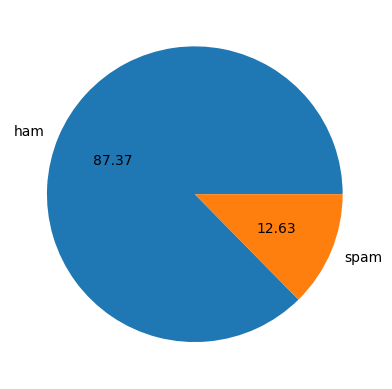

In [454]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [322]:
# Data is imbalanced

In [455]:
import nltk

In [456]:
!pip install nltk

In [457]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [458]:
df['text']

,text
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...
3,U dun say so early hor... U c already then say...
4,"Nah I don't think he goes to usf, he lives aro..."
...,...
5567,This is the 2nd time we have tried 2 contact u...
5568,Will Ì_ b going to esplanade fr home?
5569,"Pity, * was in mood for that. So...any other s..."
5570,The guy did some bitching but I acted like i'd...


In [459]:
df['num_char']=df['text'].apply(len)

In [460]:
df.head()

,target,text,num_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [461]:
nltk.download('punkt_tab')
# num of words
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [462]:
df.head()

,target,text,num_char,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [463]:
df['num_sentences']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [464]:
df.head()

,target,text,num_char,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [465]:
df[['num_char','num_words','num_sentences']].describe()

,num_char,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [466]:
#ham
df[df['target']==0][['num_char','num_words','num_sentences']].describe()

,num_char,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [467]:
#spam
df[df['target']==1][['num_char','num_words','num_sentences']].describe()

,num_char,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [468]:
import seaborn as sns

<Axes: xlabel='num_char', ylabel='Count'>

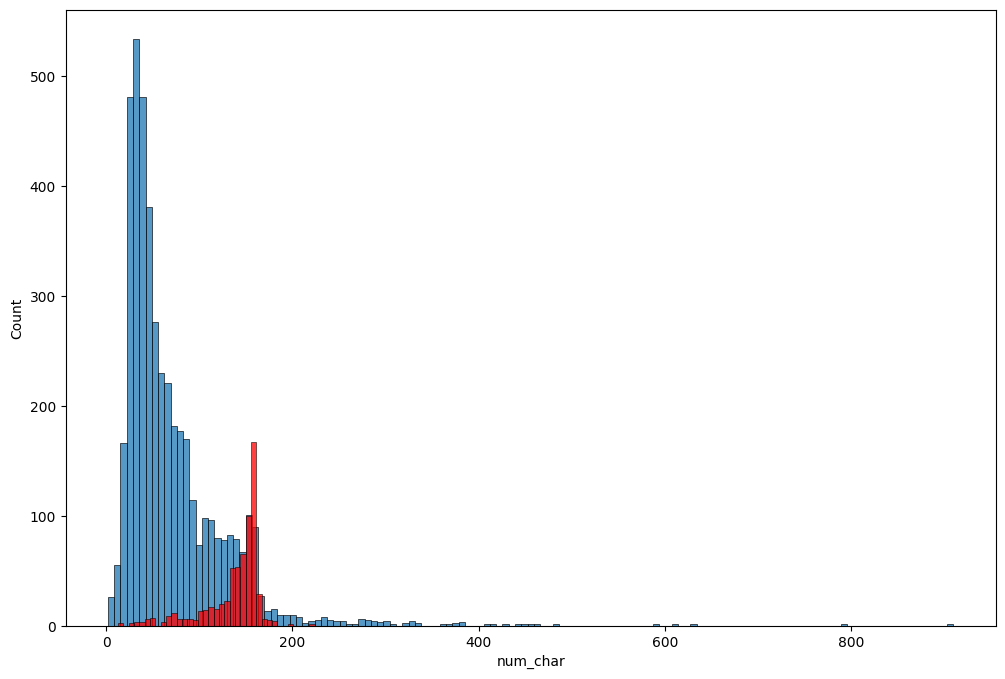

In [469]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target']==0]['num_char'])
sns.histplot(df[df['target']==1]['num_char'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

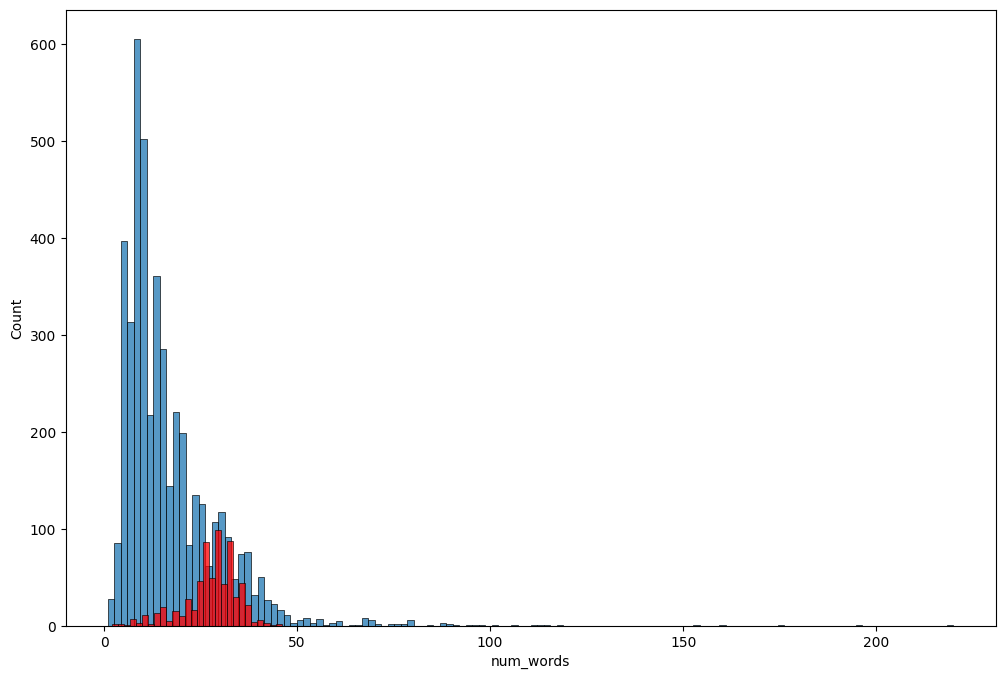

In [470]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

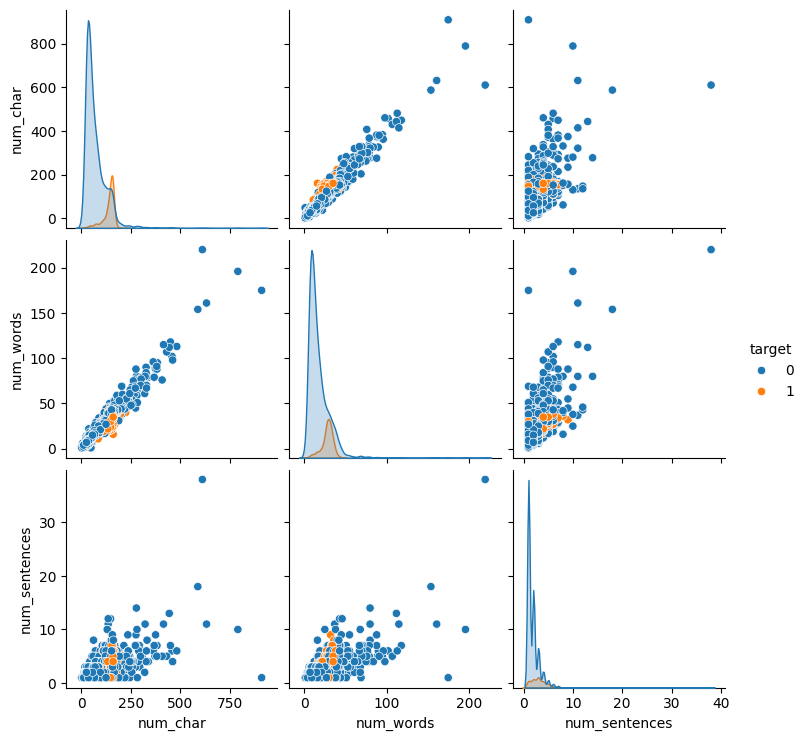

In [471]:
sns.pairplot(df,hue='target')

<Axes: >

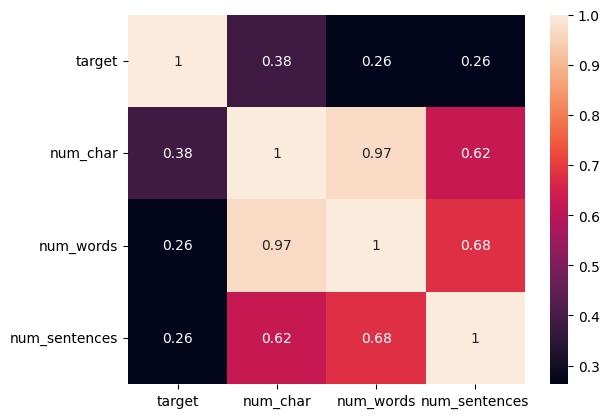

In [472]:
sns.heatmap(df[['target', 'num_char', 'num_words', 'num_sentences']].corr(),annot=True)

# **3. Data/Text Preprocessing**

*   Lower case
*   Tokenization
*   Removing special characters
*   Removing stop words and punctuation
*   Stemming






In [473]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

def transform_text(text):
  text = text.lower()
  text = nltk.word_tokenize(text)

  # 1. Remove special characters (keep alphanumeric)
  y = []
  for i in text:
    if i.isalnum():
      y.append(i)

  # 2. Remove stopwords and punctuation
  text = [] # Reuse 'text' variable
  for i in y:
    if i not in stopwords.words('english') and i not in string.punctuation:
      text.append(i)

  # 3. Apply stemming
  y = [] # Reuse 'y' variable
  for i in text:
    y.append(ps.stem(i))

  return " ".join(y)

In [474]:
import nltk
nltk.download('stopwords', quiet=True)
transform_text('Hi How Are You, Tanudip!!. I loved your work')

'hi tanudip love work'

In [475]:
df['text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [476]:
transform_text(df['text'][10])

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [477]:
df['transform_text']=df['text'].apply(transform_text)

In [478]:
df.head()

,target,text,num_char,num_words,num_sentences,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [479]:
from wordcloud import WordCloud
wc=WordCloud(width=800,height=800,min_font_size=10,background_color='white')

In [480]:
spam_wc=wc.generate(df[df['target']==1]['transform_text'].str.cat(sep=""))

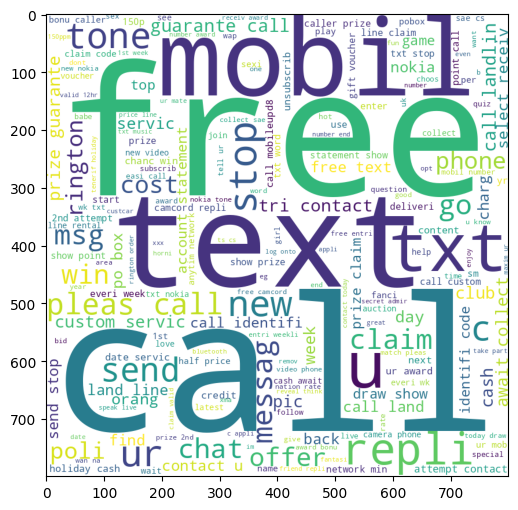

In [481]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [482]:
ham_wc=wc.generate(df[df['target']==0]['transform_text'].str.cat(sep=""))

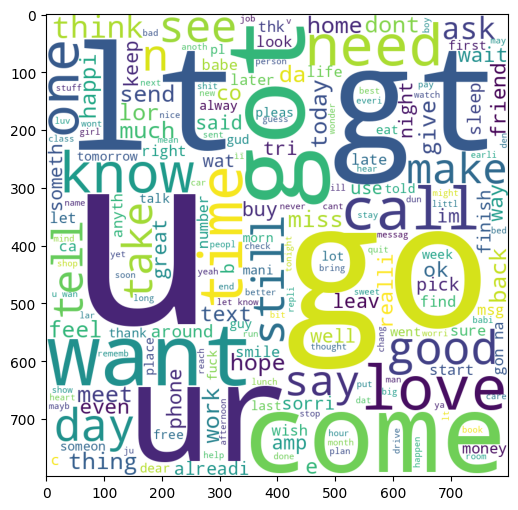

In [483]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [484]:
df.head()

,target,text,num_char,num_words,num_sentences,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [485]:
spam_corpus=[]
for msg in df[df['target']==1]['transform_text'].tolist():
  for word in msg.split():
    spam_corpus.append(word)

In [486]:
len(spam_corpus)

9939

/tmp/ipykernel_16177/283997972.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0], y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1],palette='rainbow')


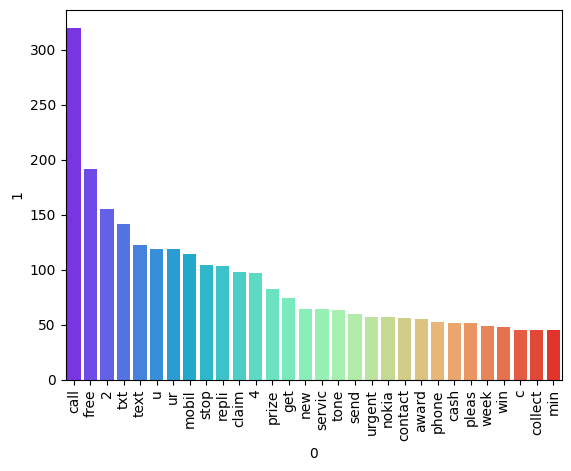

In [487]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0], y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1],palette='rainbow')
plt.xticks(rotation='vertical')
plt.show()

In [488]:
ham_corpus=[]
for msg in df[df['target']==0]['transform_text'].tolist():
  for word in msg.split():
    ham_corpus.append(word)

In [489]:
len(ham_corpus)

35404

/tmp/ipykernel_16177/3651328218.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0], y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1],palette='rainbow')


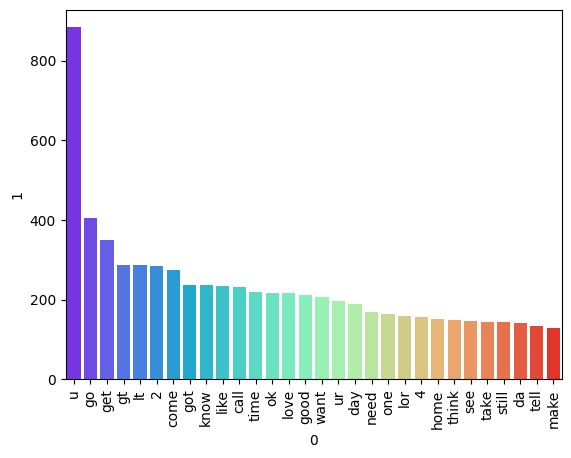

In [490]:
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0], y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1],palette='rainbow')
plt.xticks(rotation='vertical')
plt.show()

# **4. Model Building**

In [532]:
#rather than using cv(bag of words), we use TF-IDF vectorizer
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
tfidf=TfidfVectorizer(max_features=3200)

In [496]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#X = scaler.fit_transform(X)

In [497]:
#Scaling does not make any improvement
#When run this model run two times for comparison one time without max features in tfidf and one time with that.
#When you runt this two time ( first run without max feature till the predction df cell ; after that when u will run this 2nd time
#skip the prediction df column for comparison goto temp df then merge with prediction df cell that we got earlier)

In [533]:
X=tfidf.fit_transform(df['transform_text']).toarray()

In [534]:
X.shape

(5169, 3200)

In [535]:
y=df['target'].values

In [536]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [537]:
from sklearn.model_selection import train_test_split

In [538]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [539]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
#For imbalanced data precision score matters

In [540]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [530]:
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182


In [542]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

#for imbalance data our goal is to reduce false positive, though precision score matters more than accuracy we are going with that model

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [543]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9816247582205029
[[895   1]
 [ 18 120]]
0.9917355371900827


In [544]:
#tfidf --> MNB

In [545]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier


In [546]:
svc=SVC(kernel='sigmoid',gamma=1.0)
knc=KNeighborsClassifier()
mnb=MultinomialNB()
dtc=DecisionTreeClassifier(max_depth=5)
lrc=LogisticRegression(solver='liblinear',penalty='l1')
rfc=RandomForestClassifier(n_estimators=50,random_state=2)
xgb=XGBClassifier(n_estimators=50,random_state=2)
abc=AdaBoostClassifier(n_estimators=50,random_state=2)
bc=BaggingClassifier(n_estimators=50,random_state=2)
gbdt=GradientBoostingClassifier(n_estimators=50,random_state=2)


In [547]:
clfs={'SVC':svc,'KN':knc,'NB':mnb,'DT':dtc,'LR':lrc,'RF':rfc,'XGB':xgb,'ABC':abc,'BC':bc,'GBDT':gbdt}


In [548]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
  clf.fit(X_train,y_train)
  y_pred=clf.predict(X_test)
  accuracy=accuracy_score(y_test,y_pred)
  precision=precision_score(y_test,y_pred)
  return accuracy,precision

In [549]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9748549323017408, 0.9745762711864406)

In [550]:
accuracy_scores=[]
precision_scores=[]
for name,clf in clfs.items():
  current_accuracy,current_precision=train_classifier(clf,X_train,y_train,X_test,y_test)
  print("For",name)
  print("Accuracy - ",current_accuracy)
  print("Precision - ",current_precision)
  accuracy_scores.append(current_accuracy)
  precision_scores.append(current_precision)

For SVC
Accuracy -  0.9748549323017408
Precision -  0.9745762711864406
For KN
Accuracy -  0.9052224371373307
Precision -  1.0
For NB
Accuracy -  0.9709864603481625
Precision -  1.0
For DT
Accuracy -  0.9294003868471954
Precision -  0.8421052631578947
For LR
Accuracy -  0.9564796905222437
Precision -  0.9696969696969697
For RF
Accuracy -  0.9748549323017408
Precision -  0.9827586206896551
For XGB
Accuracy -  0.9690522243713733
Precision -  0.9568965517241379
For ABC
Accuracy -  0.9235976789168279
Precision -  0.8390804597701149
For BC
Accuracy -  0.9574468085106383
Precision -  0.8671875
For GBDT
Accuracy -  0.9487427466150871
Precision -  0.9292929292929293


In [516]:
performance_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [517]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.900387,1.000000
2,NB,0.959381,1.000000
5,RF,0.971954,1.000000
0,SVC,0.972921,0.974138
6,XGB,0.974855,0.951613
4,LR,0.951644,0.940000
9,GBDT,0.952611,0.923810
8,BC,0.958414,0.862595
7,ABC,0.924565,0.840909
3,DT,0.935203,0.838095


In [518]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [519]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.900387
1,NB,Accuracy,0.959381
2,RF,Accuracy,0.971954
3,SVC,Accuracy,0.972921
4,XGB,Accuracy,0.974855
5,LR,Accuracy,0.951644
6,GBDT,Accuracy,0.952611
7,BC,Accuracy,0.958414
8,ABC,Accuracy,0.924565
9,DT,Accuracy,0.935203


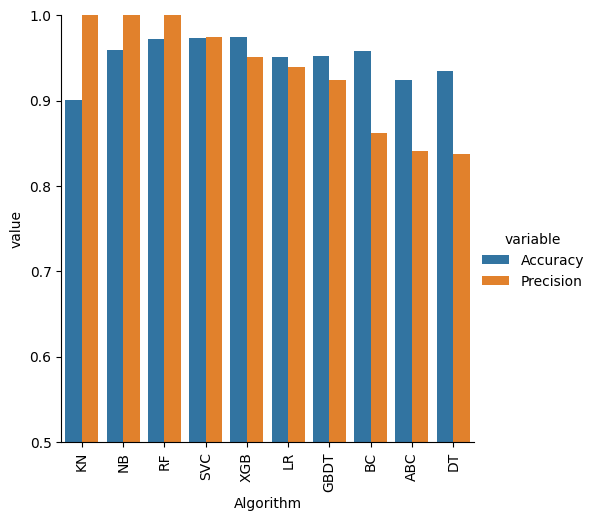

In [520]:
sns.catplot(x = 'Algorithm', y='value',
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
# model improve
# 1. Change the max_features parameter of TfIdf

In [551]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [552]:
temp_df

,Algorithm,Accuracy_max_ft_3000,Precision_max_ft_3000
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
5,RF,0.974855,0.982759
0,SVC,0.974855,0.974576
4,LR,0.956480,0.969697
6,XGB,0.969052,0.956897
9,GBDT,0.948743,0.929293
8,BC,0.957447,0.867188
3,DT,0.929400,0.842105
7,ABC,0.923598,0.839080


In [553]:
performance_df2 = pd.melt(temp_df, id_vars = "Algorithm")

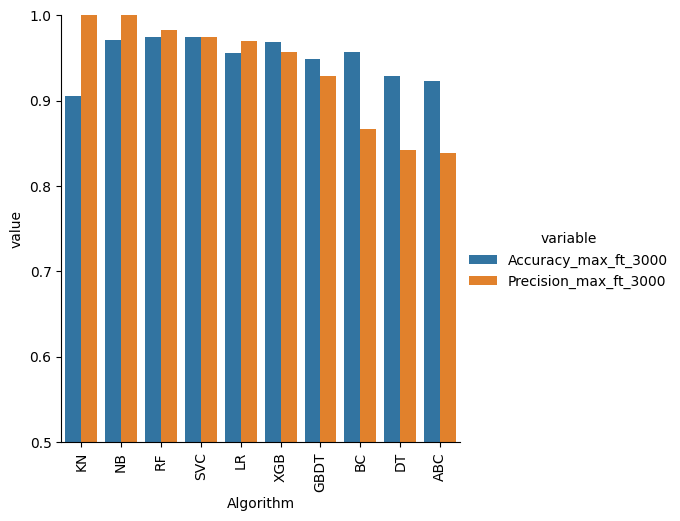

In [554]:
sns.catplot(x = 'Algorithm', y='value',
               hue = 'variable',data=performance_df2, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [555]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [556]:
new_df

,Algorithm,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000
0,KN,0.900387,1.000000,0.905222,1.000000
1,NB,0.959381,1.000000,0.970986,1.000000
2,RF,0.971954,1.000000,0.974855,0.982759
3,SVC,0.972921,0.974138,0.974855,0.974576
4,XGB,0.974855,0.951613,0.969052,0.956897
5,LR,0.951644,0.940000,0.956480,0.969697
6,GBDT,0.952611,0.923810,0.948743,0.929293
7,BC,0.958414,0.862595,0.957447,0.867188
8,ABC,0.924565,0.840909,0.923598,0.839080
9,DT,0.935203,0.838095,0.929400,0.842105


In [557]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [560]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
rfc=RandomForestClassifier(n_estimators=50,random_state=2)

from sklearn.ensemble import VotingClassifier

In [561]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('rf', rfc)],voting='soft')

In [562]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('rf',
                              RandomForestClassifier(n_estimators=50,
                                                     random_state=2))],
                 voting='soft')

In [564]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9787234042553191
Precision 0.9833333333333333


In [565]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('rf', rfc)]
final_estimator=RandomForestClassifier()

In [566]:
from sklearn.ensemble import StackingClassifier

In [567]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [568]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9816247582205029
Precision 0.9541984732824428


In [ ]:
#We select Multinomial Naive Bayes Model for prediction

### Predicting with the Multinomial Naive Bayes (MNB) Model

In [573]:
def check_sms(text):
  # Preprocess the input text
  processed_text = transform_text(text)

  # Vectorize the processed text
  vectorized_text = tfidf.transform([processed_text]).toarray()

  # Predict using the MNB model

  mnb = MultinomialNB()
  mnb.fit(X_train, y_train)
  prediction = mnb.predict(vectorized_text)

  # Interpret and return the prediction
  if prediction[0] == 1:
    return "Spam"
  else:
    return "Ham"

In [574]:
print(check_sms("WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only."))

Spam


In [575]:
print(check_sms("Hey, how are you doing?"))

Ham
